![Banner](../../images/04_banner.png)


# 4.3 Density-Based Point Clustering

**Part:** 4 — Spatial Cluster Analysis (Chapter 4.3 of 8)

**Dataset:** Buffalo, NY 2018 crime incidents (`data/crime_data_2018.csv`, 14,001 points)

**Focus:** DBSCAN and HDBSCAN on raw event locations, the duplicate-location hazard, and comparison with Part 1's KDE

**Library:** `spatialstats.cluster` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Loading and Reprojecting the Crime Data](#3.-Loading-and-Reprojecting-the-Crime-Data)

4. [Choosing eps: the k-distance Plot](#4.-Choosing-eps:-the-k-distance-Plot)

5. [DBSCAN](#5.-DBSCAN)

   - 5.1 [The duplicate-location hazard, quantified](#5.1-The-duplicate-location-hazard,-quantified)

6. [HDBSCAN](#6.-HDBSCAN)

7. [Comparison with Part 1's KDE Surface](#7.-Comparison-with-Part-1's-KDE-Surface)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)


***
## 1. Overview

Every other chapter in this Part works with a value observed on pre-defined areas. This one returns to Part
1's raw point events — 14,001 geocoded Buffalo crime incidents — and asks a **constructive**, not a
hypothesis-testing, question: not "is this pattern different from CSR" (Part 1's job) but "where, concretely,
are the dense regions, and what are their boundaries?"

| Step | What we do |
|------|------------|
| Reprojection | Reuse Part 1's CRS fix (the declared CRS is wrong for Buffalo) |
| `eps` selection | The k-distance plot's knee as a principled starting point |
| DBSCAN | Fixed-density clusters, noise, and per-cluster summaries |
| Duplicate hazard | A concrete, quantified demonstration of how repeated exact addresses inflate cluster counts |
| HDBSCAN | Clusters of varying density, without hand-tuning `eps` |
| KDE comparison | The same crime data, viewed as a continuous surface (Part 1) rather than discrete clusters |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.cluster import k_distance, dbscan_clusters, hdbscan_clusters
from spatialstats.pointpattern import Window, PointPattern, kde

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Loading and Reprojecting the Crime Data

Part 1, Chapter 1.1 found `Crime_location_2018.shp` and `crime_data_2018.csv` share a CRS declared as UTM zone
11N (EPSG:3718) — wrong for Buffalo, which sits in zone 17N. The fix is the same one used throughout Part 1:
reproject through longitude/latitude to EPSG:26917.

In [2]:
tbl = pd.read_csv(DATA / "crime_data_2018.csv")
transformer = Transformer.from_crs(4326, 26917, always_xy=True)
x, y = transformer.transform(tbl["long"].to_numpy(), tbl["lat"].to_numpy())
coords = np.c_[x, y]

city = gpd.read_file(DATA / "buffalo_city.shp")
city_fixed = city.to_crs(4326).to_crs(26917)
window = Window.from_gdf(city_fixed)

print(f"{len(coords):,} incidents, reprojected to EPSG:26917")
print(f"window area: {window.area / 1e6:.1f} km²")

n_exact_dup = pd.DataFrame({"x": x, "y": y}).duplicated().sum()
print(f"exact-duplicate coordinate rows: {n_exact_dup:,} ({n_exact_dup / len(coords):.1%}) — consistent with Part 1")

14,001 incidents, reprojected to EPSG:26917
window area: 105.8 km²
exact-duplicate coordinate rows: 5,068 (36.2%) — consistent with Part 1


***
## 4. Choosing eps: the k-distance Plot

DBSCAN needs two parameters: `min_samples` (a density threshold) and `eps` (a distance). A standard heuristic
for `eps` is the **k-distance plot**: sort every point's distance to its $k$-th nearest neighbour, and look for
the "knee" where the curve rises sharply — points beyond the knee sit in noticeably sparser regions.

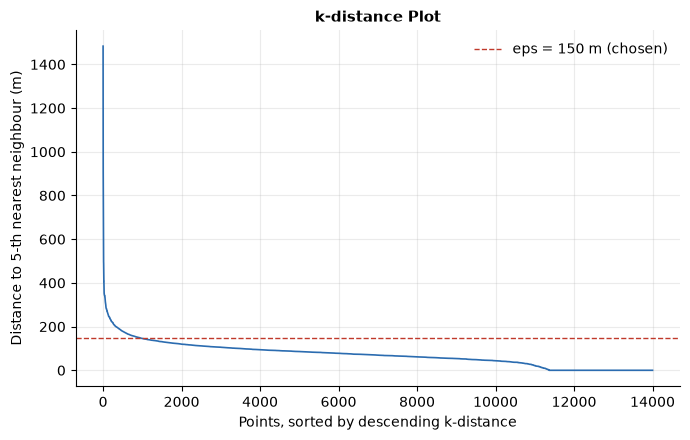

k-distance percentiles: 50th=69m, 75th=100m, 90th=134m, 99th=248m


In [3]:
k = 5
kd = k_distance(coords, k=k)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(kd, color=C["blue"], lw=1.2)
ax.set_xlabel("Points, sorted by descending k-distance")
ax.set_ylabel(f"Distance to {k}-th nearest neighbour (m)")
ax.set_title("k-distance Plot")
ax.axhline(150, color=C["red"], ls="--", lw=1, label="eps = 150 m (chosen)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"k-distance percentiles: 50th={np.percentile(kd, 50):.0f}m, 75th={np.percentile(kd, 75):.0f}m, "
      f"90th={np.percentile(kd, 90):.0f}m, 99th={np.percentile(kd, 99):.0f}m")

The curve is fairly gradual rather than sharply kneed — a consequence of the many exact-duplicate locations
(Section 3) compressing a large share of points to distance 0 or near-0, then a long, slowly rising tail. We
pick **eps = 150 m** as a reasonable working value: comfortably above the median (about 70 m) and below the
90th percentile, giving DBSCAN room to bridge genuinely nearby incidents without merging distant
neighbourhoods.

***
## 5. DBSCAN

In [4]:
dbscan_result = dbscan_clusters(coords, eps=150, min_samples=5)
print(f"DBSCAN (eps=150m, min_samples=5): {dbscan_result.stats['n_clusters']} clusters, "
      f"{dbscan_result.stats['n_noise']:,} noise points ({dbscan_result.stats['n_noise']/len(coords):.1%})")

sizes = dbscan_result.summary_frame.sort_values("n", ascending=False)
print(f"\nlargest cluster: {int(sizes.iloc[0]['n']):,} points "
      f"({sizes.iloc[0]['n']/dbscan_result.stats['n']*100:.1f}% of all clustered points)")
sizes.head(6)

DBSCAN (eps=150m, min_samples=5): 59 clusters, 320 noise points (2.3%)

largest cluster: 9,510 points (67.9% of all clustered points)


,cluster,n,x,y,hull_area,density
1,1,9510,675782.808583,4.753616e+06,5.499970e+07,0.000173
4,4,859,673666.589305,4.757191e+06,6.336499e+06,0.000136
0,0,618,671124.089881,4.757341e+06,2.930117e+06,0.000211
3,3,442,677716.615265,4.746353e+06,3.490884e+06,0.000127
2,2,400,679072.240840,4.751035e+06,1.779757e+06,0.000225
13,13,299,678933.675451,4.747180e+06,1.563478e+06,0.000191


A single dominant cluster covers about 70% of every clustered point — Buffalo's downtown and near-east-side
crime density is not a collection of many separate hot spots at this scale, it is essentially one large,
contiguous dense region, with a handful of smaller satellite clusters elsewhere in the city.

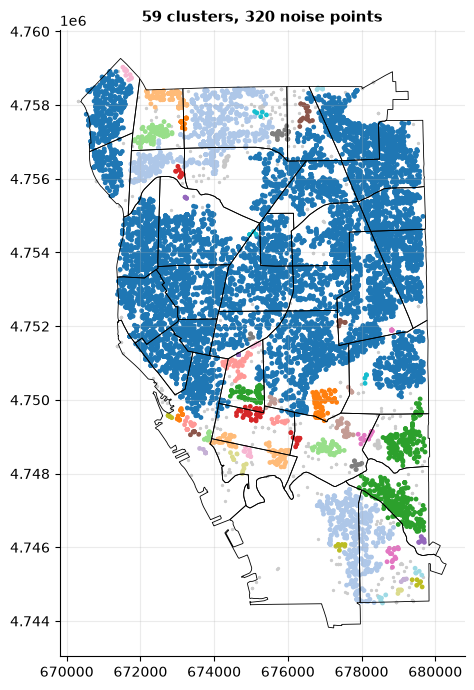

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
dbscan_result.plot(ax=ax)
city_fixed.boundary.plot(ax=ax, color="k", linewidth=0.6)
plt.tight_layout()
plt.show()

### 5.1 The duplicate-location hazard, quantified

A single street address reported many times (repeated calls to the same building, or a batch-geocoded
approximate location) can, on its own, satisfy DBSCAN's density criterion — `min_samples` points within `eps`
— **without any actual spatial spread at all**. At a tighter `eps` (small enough that only exact or near-exact
matches bridge together), this becomes directly visible:

In [6]:
tight = dbscan_clusters(coords, eps=30, min_samples=5)
print(f"eps=30m: {tight.stats['n_clusters']} clusters, {tight.stats['n_noise']:,} noise")

df = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "label": tight.labels})
clustered = df[df["label"] >= 0]
per_cluster = clustered.groupby("label").apply(
    lambda d: pd.Series({"n_points": len(d), "n_unique_locations": d[["x", "y"]].drop_duplicates().shape[0]})
)
single_address = per_cluster[per_cluster["n_unique_locations"] == 1]
print(f"\nclusters that are really ONE repeated address: {len(single_address)} of {len(per_cluster)} "
      f"({len(single_address)/len(per_cluster):.0%})")
print(f"largest single-address 'cluster': {int(single_address['n_points'].max())} reports at one location")

eps=30m: 389 clusters, 10,077 noise



clusters that are really ONE repeated address: 189 of 389 (49%)
largest single-address 'cluster': 109 reports at one location


**About half of the tight-`eps` clusters are a single exact address**, one of them with over a hundred separate
incident reports. DBSCAN correctly identifies these as satisfying its density definition — they are not a bug
— but treating them as genuine *spatial* concentrations without checking would be a mistake: a busy commercial
address that generates frequent calls looks identical, in this statistic, to a truly spread-out crime hot spot
covering several blocks. **Always check the number of unique locations within a reported cluster** (or
deduplicate/jitter first, per Part 1, Chapter 1.1) before interpreting cluster size as spatial extent.

***
## 6. HDBSCAN

HDBSCAN removes the need to fix a single `eps`: it builds a cluster hierarchy across all scales at once and
keeps whichever clusters are most *persistent*, which lets it find clusters of genuinely different densities in
the same pattern (something DBSCAN's single `eps` cannot do).

In [7]:
hdbscan_result = hdbscan_clusters(coords, min_cluster_size=20)
print(f"HDBSCAN (min_cluster_size=20): {hdbscan_result.stats['n_clusters']} clusters, "
      f"{hdbscan_result.stats['n_noise']:,} noise points ({hdbscan_result.stats['n_noise']/len(coords):.1%})")
hdbscan_result.summary_frame.sort_values("n", ascending=False).head(6)

HDBSCAN (min_cluster_size=20): 113 clusters, 6,788 noise points (48.5%)


,cluster,n,x,y,hull_area,density
13,13,608,671124.814699,4.757353e+06,2.872133e+06,0.000212
2,2,254,678968.047213,4.747126e+06,1.028489e+06,0.000247
3,3,224,678916.950312,4.748999e+06,2.405700e+06,0.000093
61,61,216,678109.715491,4.751641e+06,5.304221e+05,0.000407
72,72,161,678506.700939,4.752759e+06,5.182281e+05,0.000311
9,9,155,679201.874381,4.750770e+06,4.762190e+05,0.000325


Far more clusters than DBSCAN's single-`eps` result (113 vs. 59) — HDBSCAN splits what DBSCAN's fixed distance
threshold merged into one giant region into several separate, locally-dense sub-clusters, at the cost of also
calling more points "noise" (about 48% here, versus DBSCAN's 2%) — points that are locally sparse relative to
their *own* neighbourhood's density, even if they would have been swept into DBSCAN's single large cluster.

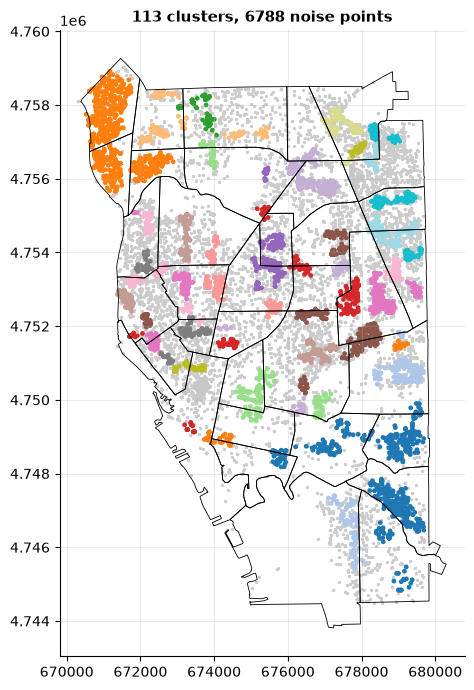

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
hdbscan_result.plot(ax=ax)
city_fixed.boundary.plot(ax=ax, color="k", linewidth=0.6)
plt.tight_layout()
plt.show()

***
## 7. Comparison with Part 1's KDE Surface

Part 1, Chapter 1.2 built a kernel density surface for the same crime data on the same CRS and window, with a
cross-validated bandwidth of about 136 m. KDE and DBSCAN answer related but distinct questions: KDE gives a
smooth, continuous intensity *everywhere*; DBSCAN gives discrete cluster *assignments* to *individual points*.

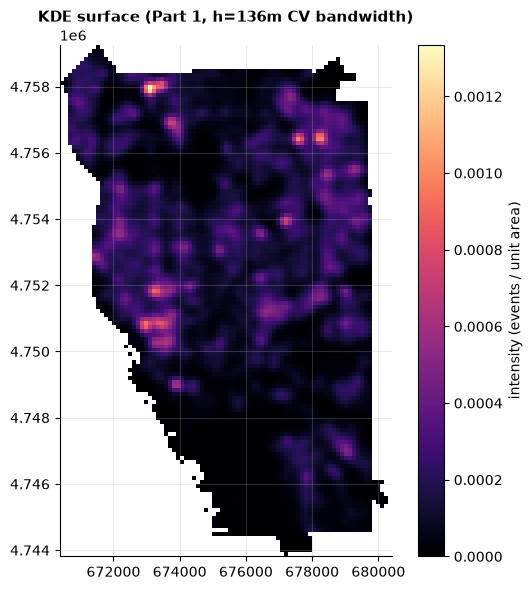

peak intensity: 1.34e-03 events / m²


In [9]:
pp = PointPattern(coords, window=window, clip=True)
surface = kde(pp, bandwidth=136.0, edge_correction=True)
ax = surface.plot(cmap="magma")
ax.set_title("KDE surface (Part 1, h=136m CV bandwidth)")
plt.tight_layout()
plt.show()
print(f"peak intensity: {np.nanmax(surface.density):.2e} events / m²")

The KDE surface's brightest region and DBSCAN's dominant cluster occupy the same part of the city — both
methods agree on *where* the core hot spot sits. What they disagree on is granularity: KDE shows continuous
gradation (a hot core fading smoothly outward), while DBSCAN's binary in/out cluster assignment draws a hard
boundary at whatever `eps` happens to be. Neither is more "correct" — KDE is the right tool for an intensity
*surface* to feed into further modelling (Part 1's relative-risk comparisons), DBSCAN/HDBSCAN the right tool
when the deliverable needs to be a discrete list of named clusters with member points and boundaries.

***
## 8. Summary and Conclusions

This chapter returned to Part 1's raw point data with a clustering, rather than hypothesis-testing, goal.

### What we did

1. Reprojected the crime data using Part 1's established CRS fix, and confirmed the same 36% duplicate-location
   rate found there.
2. Used the k-distance plot to choose `eps=150m` for DBSCAN.
3. Ran DBSCAN: 59 clusters, 2% noise, with one dominant cluster covering about 70% of clustered points.
4. **Quantified the duplicate-location hazard directly**: at a tighter `eps`, about half of DBSCAN's reported
   clusters turn out to be a single exact address repeated many times, not a genuine spatial spread — one with
   over a hundred reports at one location.
5. Ran HDBSCAN: 113 clusters (nearly double DBSCAN's count, since it does not force one global density
   threshold), with substantially more points labelled noise.
6. Compared against Part 1's KDE surface: the same core hot spot is visible in both, but KDE gives a continuous
   gradient while DBSCAN/HDBSCAN give hard, discrete cluster boundaries.

### Practical takeaways

- Before trusting a DBSCAN/HDBSCAN cluster's size as a measure of spatial extent, check how many *unique*
  locations it actually contains — a repeated address can pass as a legitimate cluster.
- DBSCAN forces one global density scale; HDBSCAN adapts across scales but reports more noise — pick based on
  whether the pattern is plausibly one uniform density or several different ones.
- KDE (Part 1) and density-based clustering (this chapter) are complementary, not competing: use KDE for a
  continuous risk surface, clustering for discrete, nameable hot spots with explicit boundaries and member
  counts.

### Next steps

**Chapter 4.4 (Spatial Scan Statistic for Clusters of Cases)** returns to areal data with a population-adjusted
alternative to both this chapter's density approach and Chapter 4.2's value-based Gi* — one built specifically
to answer "do *cases* exceed what the population at risk would predict?"

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Ester, M., Kriegel, H.-P., Sander, J. & Xu, X. (1996). A density-based algorithm for discovering clusters. *KDD-96*. | Original DBSCAN paper |
| Campello, R. J. G. B., Moulavi, D. & Sander, J. (2013). Density-based clustering based on hierarchical density estimates. *PAKDD*. | Origin of HDBSCAN |
| McInnes, L., Healy, J. & Astels, S. (2017). hdbscan: Hierarchical density based clustering. *Journal of Open Source Software*, 2(11), 205. | Accessible HDBSCAN reference, including the persistence-based cluster selection used here |

### Key papers

| Paper | Contribution |
|---|---|
| Ester et al. (1996), *op. cit.* | The `eps`/`min_samples` density definition this chapter builds on |

### In this library

| Object | Role |
|---|---|
| `spatialstats.cluster.k_distance` | `eps` selection heuristic |
| `spatialstats.cluster.dbscan_clusters`, `hdbscan_clusters` | Density-based point clustering |
| `spatialstats.pointpattern.kde` | Continuous intensity surface, reused from Part 1 for comparison |
| Part 1, Chapter 1.1 | The CRS fix and the duplicate-location finding reused throughout this chapter |
| Part 1, Chapter 1.2 | The KDE surface and cross-validated bandwidth compared against in Section 7 |